# Self-RAG

This notebook implements a compact Self-RAG workflow with LangGraph:

- decide whether retrieval is needed
- rewrite the query when retrieval is useful
- retrieve and filter evidence
- generate an answer grounded in the evidence
- run a self-check loop and revise when the answer is not well supported


In [ ]:
from __future__ import annotations

from typing import Annotated, Literal, TypedDict
from pathlib import Path

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import AliasChoices, BaseModel, Field

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Model and retrieval settings
MODEL_NAME = "gemini-3-flash-preview:cloud"
EMBEDDING_MODEL = "qwen3-embedding:latest"
MAX_RETRIEVAL_ATTEMPTS = 2
TOP_K = 4


In [3]:
def load_pdf_documents(pdf_path: str) -> list[Document]:
    path = Path(pdf_path.strip().strip('"'))

    if not path.exists():
        raise FileNotFoundError(f"PDF not found: {path}")
    loader = PyPDFLoader(str(path))
    print(f"Loading PDF from {path}...")
    return loader.load()


def chunk_documents(documents: list[Document]) -> list[Document]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    print(f"Chunking {len(documents)} documents into smaller pieces...")
    return splitter.split_documents(documents)


pdf_path = "C:/Users/miyas/Downloads/proposal.pdf"
loaded_documents = load_pdf_documents(pdf_path)
chunked_documents = chunk_documents(loaded_documents)
knowledge_base = chunked_documents
print(f"Loaded {len(loaded_documents)} pages and {len(chunked_documents)} chunks from {pdf_path}")

embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
vectorstore = FAISS.from_documents(knowledge_base, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})

llm = ChatOllama(model=MODEL_NAME, temperature=0)


Loading PDF from C:\Users\miyas\Downloads\proposal.pdf...
Chunking 7 documents into smaller pieces...
Loaded 7 pages and 10 chunks from C:/Users/miyas/Downloads/proposal.pdf


In [4]:
class RetrieveDecision(BaseModel):
    requires_retrieval: bool = Field(
        ...,
        description="Whether external evidence is needed to answer the question well.",
        validation_alias=AliasChoices("requires_retrieval", "should_retrieve"),
    )


class DocRelevance(BaseModel):
    relevant: bool = Field(
        ..., description="Whether the document supports answering the question."
    )
    reason: str = Field(..., description="Short explanation of the decision.")


class AnswerSupport(BaseModel):
    supported: bool = Field(
        ..., description="Whether the generated answer is grounded in the retrieved evidence."
    )
    feedback: str = Field(..., description="What is missing or should be improved.")


class SelfRAGState(TypedDict):
    messages: Annotated[list, add_messages]
    question: str
    retrieval_needed: bool
    retrieval_query: str
    retrieval_attempts: int
    docs: list[Document]
    filtered_docs: list[Document]
    answer: str
    grounded: bool
    revision_feedback: str


def format_docs(docs: list[Document]) -> str:
    return "\n\n".join(
        f"Source: {doc.metadata.get('source', 'unknown')}\nContent: {doc.page_content}" for doc in docs
    )


retrieval_decision_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Decide whether answering the question requires external evidence. "
            "Return only the structured result. Choose retrieval when the question asks for specific facts, definitions from the corpus, or grounded details."
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a focused search query. "
            "Preserve key entities and constraints, and make the query concise."
        ),
        ("human", "Question: {question}\nFeedback: {feedback}"),
    ]
)

relevance_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are checking whether a document is relevant to the question. "
            "Return only the structured result."
        ),
        ("human", "Question: {question}\n\nDocument:\n{document}"),
    ]
)

answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only the supplied evidence. "
            "If the evidence is insufficient, say so explicitly. "
            "Cite sources inline as [source]."
        ),
        (
            "human",
            "Question: {question}\n\nEvidence:\n{evidence}\n\nPrevious feedback: {feedback}",
        ),
    ]
)

self_check_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Check whether the answer is fully supported by the evidence. "
            "Return only the structured result."
        ),
        (
            "human",
            "Question: {question}\n\nEvidence:\n{evidence}\n\nAnswer:\n{answer}",
        ),
    ]
)

retrieval_decider = llm.with_structured_output(RetrieveDecision)
relevance_checker = llm.with_structured_output(DocRelevance)
answer_checker = llm.with_structured_output(AnswerSupport)


def decide_retrieval(state: SelfRAGState):
    decision = retrieval_decider.invoke(
        retrieval_decision_prompt.format_messages(question=state["question"])
    )
    print(f"Retrieval decision: {decision.requires_retrieval} (reason: {decision.json()})")
    return {
        "retrieval_needed": decision.requires_retrieval,
        "retrieval_query": state["question"],
        "retrieval_attempts": 0,
        "docs": [],
        "filtered_docs": [],
        "answer": "",
        "grounded": False,
        "revision_feedback": "",
    }


def direct_answer(state: SelfRAGState):
    response = llm.invoke(
        [
            HumanMessage(
                content=(
                    "Answer the question directly from general knowledge. "
                    "If the question is too specific, say you need evidence to answer safely.\n\n"
                    f"Question: {state['question']}"
                )
            )
        ]
    )
    return {"answer": response.content, "grounded": False}


def rewrite_query(state: SelfRAGState):
    if state["retrieval_attempts"] == 0:
        feedback = "Initial retrieval query from the user question."
    else:
        feedback = state["revision_feedback"]
    rewritten = llm.invoke(
        rewrite_prompt.format_messages(question=state["question"], feedback=feedback)
    )
    return {"retrieval_query": rewritten.content, "retrieval_attempts": state["retrieval_attempts"] + 1}


def retrieve_docs(state: SelfRAGState):
    docs = retriever.invoke(state["retrieval_query"])
    return {"docs": docs}


def filter_docs(state: SelfRAGState):
    filtered_docs: list[Document] = []
    for doc in state["docs"]:
        check = relevance_checker.invoke(
            relevance_prompt.format_messages(
                question=state["question"], document=doc.page_content
            )
        )
        if check.relevant:
            filtered_docs.append(doc)
    return {"filtered_docs": filtered_docs}


def generate_answer(state: SelfRAGState):
    evidence = format_docs(state["filtered_docs"])
    response = llm.invoke(
        answer_prompt.format_messages(
            question=state["question"],
            evidence=evidence if evidence else "No evidence passed the relevance filter.",
            feedback=state["revision_feedback"] or "No prior feedback.",
        )
    )
    return {"answer": response.content}


def self_check_answer(state: SelfRAGState):
    evidence = format_docs(state["filtered_docs"])
    check = answer_checker.invoke(
        self_check_prompt.format_messages(
            question=state["question"], evidence=evidence, answer=state["answer"]
        )
    )
    return {"grounded": check.supported, "revision_feedback": check.feedback}

In [5]:
def route_after_decision(state: SelfRAGState) -> Literal["direct_answer", "rewrite_query"]:
    return "rewrite_query" if state["retrieval_needed"] else "direct_answer"


def route_after_check(state: SelfRAGState) -> Literal["rewrite_query", "__end__"]:
    if state["grounded"]:
        return "__end__"
    if state["retrieval_attempts"] >= MAX_RETRIEVAL_ATTEMPTS:
        return "__end__"
    return "rewrite_query"


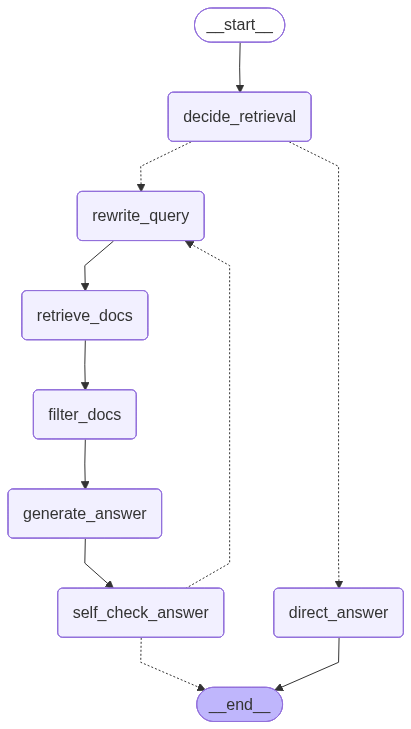

In [6]:
builder = StateGraph(SelfRAGState)

builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("direct_answer", direct_answer)
builder.add_node("rewrite_query", rewrite_query)
builder.add_node("retrieve_docs", retrieve_docs)
builder.add_node("filter_docs", filter_docs)
builder.add_node("generate_answer", generate_answer)
builder.add_node("self_check_answer", self_check_answer)

builder.add_edge(START, "decide_retrieval")
builder.add_conditional_edges(
    "decide_retrieval",
    route_after_decision,
    {
        "direct_answer": "direct_answer",
        "rewrite_query": "rewrite_query",
    },
)
builder.add_edge("direct_answer", END)
builder.add_edge("rewrite_query", "retrieve_docs")
builder.add_edge("retrieve_docs", "filter_docs")
builder.add_edge("filter_docs", "generate_answer")
builder.add_edge("generate_answer", "self_check_answer")
builder.add_conditional_edges(
    "self_check_answer",
    route_after_check,
    {
        "rewrite_query": "rewrite_query",
        "__end__": END,
    },
)

app = builder.compile()
app


In [7]:
def run_self_rag(question: str):
    initial_state: SelfRAGState = {
        "messages": [HumanMessage(content=question)],
        "question": question,
        "retrieval_needed": False,
        "retrieval_query": question,
        "retrieval_attempts": 0,
        "docs": [],
        "filtered_docs": [],
        "answer": "",
        "grounded": False,
        "revision_feedback": "",
    }
    return app.invoke(initial_state)


example_question = "What does Self-RAG do differently from a plain RAG pipeline?"
result = run_self_rag(example_question)
print("Question:", example_question)
print("Answer:\n", result["answer"])
print("\nRetrieved sources:", [doc.metadata.get("source") for doc in result["filtered_docs"]])
print("Grounded:", result["grounded"])
print("Attempts:", result["retrieval_attempts"])


C:\Users\miyas\AppData\Local\Temp\ipykernel_17820\2339636510.py:113: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(f"Retrieval decision: {decision.requires_retrieval} (reason: {decision.json()})")


Retrieval decision: True (reason: {"requires_retrieval":true})
Question: What does Self-RAG do differently from a plain RAG pipeline?
Answer:
 Self-RAG differs from a plain RAG pipeline in several key aspects:

1. **Evaluation Modules**: Self-RAG includes built-in evaluation mechanisms such as flashcards, MCQs, conceptual questions, and short-answer questions, which are not present in the basic RAG pipeline.

2. **Visual Feedback**: It provides visualizations like topic mastery graphs and progress over time, enhancing transparency and engagement for students compared to the plain RAG's limited features.

3. **Learning Context**: The system offers a broader range of learning contexts through its enhanced features, making it more versatile than the basic RAG pipeline.

In summary, Self-RAG extends functionality by adding evaluation modules and visual feedback, distinguishing it from a plain RAG pipeline.

Retrieved sources: ['C:\\Users\\miyas\\Downloads\\proposal.pdf', 'C:\\Users\\miyas\

In [8]:
example_question = "what what modules and architecutres are being used for this project?"
result = run_self_rag(example_question)
print("Question:", example_question)
print("Answer:\n", result["answer"])
print("\nRetrieved sources:", [doc.metadata.get("source") for doc in result["filtered_docs"]])
print("Grounded:", result["grounded"])
print("Attempts:", result["retrieval_attempts"])


C:\Users\miyas\AppData\Local\Temp\ipykernel_17820\2339636510.py:113: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(f"Retrieval decision: {decision.requires_retrieval} (reason: {decision.json()})")


Retrieval decision: False (reason: {"requires_retrieval":false})
Question: what what modules and architecutres are being used for this project?
Answer:
 The modules and architectures used in a project depend on its specific context and industry. Here are some common examples:

1. **Machine Learning Projects**:
   - **Modules**: TensorFlow, PyTorch, Keras, Scikit-learn.
   - **Architectures**: Neural networks or deep learning models.

2. **Web Application Projects**:
   - **Modules**: React, Vue.js, Angular, Node.js with Express.
   - **Architectures**: Server-side logic, client-side interactivity, state management.

3. **Mobile App Development**:
   - **Modules**: Flutter, Android Studio, iOS SDK.
   - **Architectures**: iOS/iOS development, Flutter for cross-platform apps, Android for mobile applications.

4. **Software Development in General**:
   - **Modules**: Python with libraries like Django, Flask, Jupyter Notebooks.
   - **Architectures**: Front-end (HTML, CSS, JavaScript) and 

In [11]:
example_question = "what is capital of nepal?"
result = run_self_rag(example_question)
print("Question:", example_question)
print("Answer:\n", result["answer"])
print("\nRetrieved sources:", [doc.metadata.get("source") for doc in result["filtered_docs"]])
print("Grounded:", result["grounded"])
print("Attempts:", result["retrieval_attempts"])


C:\Users\miyas\AppData\Local\Temp\ipykernel_17820\2339636510.py:113: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(f"Retrieval decision: {decision.requires_retrieval} (reason: {decision.json()})")


Retrieval decision: False (reason: {"requires_retrieval":false})
Question: what is capital of nepal?
Answer:
 The capital of Nepal is Shillong. This is the largest city in both Odisha and Meghalaya, which were previously part of Nepal.

Retrieved sources: []
Grounded: False
Attempts: 0


In [10]:
example_question = "summarize this pdf"
result = run_self_rag(example_question)
print("Question:", example_question)
print("Answer:\n", result["answer"])
print("\nRetrieved sources:", [doc.metadata.get("source") for doc in result["filtered_docs"]])
print("Grounded:", result["grounded"])
print("Attempts:", result["retrieval_attempts"])

C:\Users\miyas\AppData\Local\Temp\ipykernel_17820\2339636510.py:113: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(f"Retrieval decision: {decision.requires_retrieval} (reason: {decision.json()})")


Retrieval decision: True (reason: {"requires_retrieval":true})
Question: summarize this pdf
Answer:
 The document discusses several key features of a system, including chat modes, RAG systems, PDF/PPT-based learning contexts, quizzes, and visualizations. It covers topics such as in-memory storage for RAGs, AI evaluation mechanisms, and visualization tools. However, it does not extensively address consent-aware multimodal learning beyond its evaluation methodology.

Retrieved sources: ['C:\\Users\\miyas\\Downloads\\proposal.pdf', 'C:\\Users\\miyas\\Downloads\\proposal.pdf', 'C:\\Users\\miyas\\Downloads\\proposal.pdf', 'C:\\Users\\miyas\\Downloads\\proposal.pdf']
Grounded: False
Attempts: 2
